# Análise das Desigualdades Socioespaciais em Fortaleza

Este notebook investiga a distribuição espacial de indicadores demográficos nos **setores censitários de Fortaleza**, combinando dados geográficos e estatísticos do **Censo Demográfico 2022 do IBGE**.

**Fontes de dados:**
- `CE_setores_CD2022.gpkg`: malha vetorial com os polígonos dos setores censitários do Ceará
- `Agregados_por_setores_demografia_BR.csv`: tabela com variáveis de população (sexo e faixa etária) por setor censitário

**Estrutura do notebook:**
1. Configuração do ambiente
2. Carregando e explorando a malha de setores censitários
3. Filtrando os setores de Fortaleza
4. Carregando os dados demográficos agregados
5. Integrando os dois conjuntos de dados

## 1. Configuração do ambiente

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

%matplotlib inline

## 2. Malha de Setores Censitários do Ceará

Os **setores censitários** são a menor unidade territorial operacional do IBGE, o nível mais detalhado em que os dados do censo são coletados e divulgados. O arquivo `CE_setores_CD2022.gpkg` (formato GeoPackage) contém os polígonos geográficos de todos os setores do estado do Ceará.

O carregamento é feito com `geopandas.read_file()`, que retorna um `GeoDataFrame`, uma extensão do `DataFrame` do pandas com uma coluna especial `geometry` contendo as geometrias vetoriais de cada setor.

> **Download:** os arquivos de malha por UF estão disponíveis no [site do IBGE](https://www.ibge.gov.br/geociencias/downloads-geociencias.html), em Organização do Território > Malhas Territoriais > Malhas de Setores Censitários > Censo 2022 > Setores > gpkg > UF > CE > CE_setores_CD2022.gpkg.

In [2]:
setores_ce = gpd.read_file("data/CE_setores_CD2022.gpkg")

print(f"Setores no Ceará: {len(setores_ce):,}")
print(f"CRS (sistema de referência): {setores_ce.crs}")
print(f"\nColunas ({len(setores_ce.columns)}):")
setores_ce.columns.tolist()

Setores no Ceará: 20,982
CRS (sistema de referência): EPSG:4674

Colunas (30):


['CD_SETOR',
 'SITUACAO',
 'CD_SIT',
 'CD_TIPO',
 'AREA_KM2',
 'CD_REGIAO',
 'NM_REGIAO',
 'CD_UF',
 'NM_UF',
 'CD_MUN',
 'NM_MUN',
 'CD_DIST',
 'NM_DIST',
 'CD_SUBDIST',
 'NM_SUBDIST',
 'CD_BAIRRO',
 'NM_BAIRRO',
 'CD_NU',
 'NM_NU',
 'CD_FCU',
 'NM_FCU',
 'CD_AGLOM',
 'NM_AGLOM',
 'CD_RGINT',
 'NM_RGINT',
 'CD_RGI',
 'NM_RGI',
 'CD_CONCURB',
 'NM_CONCURB',
 'geometry']

O CRS (Coordinate Reference System) define como as coordenadas armazenadas no arquivo devem ser interpretadas na superfície da Terra. No caso dos nossos dados temos que o CRS é EPSG:4674. EPSG é um catálogo internacional de sistemas de coordenadas com cada CRS tendo um código EPSG único. 

Observação: EPSG:4674 (SIRGAS 2000) e EPSG:4326 (WGS84) usam latitude e longitude em graus, enquanto EPSG:31984 (UTM 24S) e EPSG:31985 (UTM 25S) usam coordenadas em metros, sendo mais adequados para cálculos de área e distância.

isso significa que os dados estão no sistema geodésico SIRGAS 2000 que é o sistema de referência oficial adotado pelo Brasil para cartografia e geoprocessamento.

Ele define:

- o formato da Terra (elipsoide);
- a posição do sistema de coordenadas;
- como latitude e longitude são medidas.


In [16]:
import pandas as pd
dicio = pd.read_excel(
    "data/Dicionario_de_dados_malha_agregados.xlsx"
)

print(f"Linhas do dicionário: {len(dicio):,}")
print(f"Colunas: {len(dicio.columns)}")

dicio.head(56)

Linhas do dicionário: 56
Colunas: 3


,VARIÁVEL,CATEGORIAS,DESCRIÇÃO
0,CD_SETOR,NaN,Geocódigo de Setor Censitário
1,SITUACAO,NaN,Situação do Setor Censitário
2,NaN,Urbana,Urbana
3,NaN,Rural,Rural
4,CD_SITUACAO,NaN,Situação detalhada do Setor Censitário
5,NaN,1,Área urbana de alta densidade de edificações d...
6,NaN,2,Área urbana de baixa densidade de edificações ...
7,NaN,3,Núcleo urbano
8,NaN,5,Aglomerado rural - Povoado
9,NaN,6,Aglomerado rural - Núcleo rural


### Dicionário de colunas: Malha de Setores Censitários

Fonte: `Dicionario_de_dados_malha_agregados.xlsx`, Censo Demográfico 2022 - [IBGE](https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html?edicao=41852&t=resultados).


| Coluna | Descrição |
|--------|-----------|
| `CD_SETOR` | Geocódigo único do setor censitário (15 dígitos) |
| `SITUACAO` | Situação geral do setor: `Urbana` ou `Rural` |
| `CD_SIT` | Situação detalhada: `1` Urbana alta densidade · `2` Urbana baixa densidade · `3` Núcleo urbano · `5` Aglomerado rural – Povoado · `6` Aglomerado rural – Núcleo rural · `7` Aglomerado rural – Lugarejo · `8` Área rural · `9` Massas de água |
| `CD_TIPO` | Tipo especial do setor: `0` Comum · `1` Favela/Comunidade Urbana · `2` Quartel/Base militar · `3` Alojamento/Acampamento · `4` Baixo patamar domiciliar · `5` Agrupamento indígena · `6` Unidade prisional · `7` Convento/Hospital/ILPI · `8` Agrovila do PA · `9` Agrupamento quilombola |
| `AREA_KM2` | Área do setor em quilômetros quadrados |
| `CD_REGIAO` / `NM_REGIAO` | Código e nome da Grande Região (ex: `2` - Nordeste) |
| `CD_UF` / `NM_UF` | Código e nome da Unidade da Federação (ex: `23` - Ceará) |
| `CD_MUN` / `NM_MUN` | Código e nome do Município |
| `CD_DIST` / `NM_DIST` | Código e nome do Distrito |
| `CD_SUBDIST` / `NM_SUBDIST` | Código e nome do Subdistrito |
| `CD_BAIRRO` / `NM_BAIRRO` | Código e nome do Bairro (quando disponível) |
| `CD_NU` / `NM_NU` | Código e nome do Núcleo Urbano |
| `CD_FCU` / `NM_FCU` | Código e nome da Favela ou Comunidade Urbana |
| `CD_AGLOM` / `NM_AGLOM` | Código e nome do Aglomerado (rural ou urbano) |
| `CD_RGINT` / `NM_RGINT` | Código e nome da Região Geográfica Intermediária |
| `CD_RGI` / `NM_RGI` | Código e nome da Região Geográfica Imediata |
| `CD_CONCURB` / `NM_CONCURB` | Código e nome da Concentração Urbana |
| `geometry` | Polígono vetorial do setor (tipo `MultiPolygon` ou `Polygon`) |

## 3. Filtrando os Setores de Fortaleza

O GeoDataFrame do Ceará contém setores de todos os municípios do estado. Filtramos apenas Fortaleza pelo nome do município (`NM_MUN`).

Para análise posterior, mantemos apenas as colunas mais relevantes da malha, descartando campos de outras divisões administrativas que não serão usados.

In [3]:
setores_fortaleza = setores_ce[setores_ce["NM_MUN"] == "Fortaleza"].copy()

colunas_interesse = [
    "CD_SETOR", "SITUACAO", "CD_SIT", "CD_TIPO",
    "AREA_KM2", "NM_BAIRRO", "geometry"
]
setores_fortaleza = setores_fortaleza[colunas_interesse].reset_index(drop=True)

print(f"Setores censitários em Fortaleza: {len(setores_fortaleza):,}")
print(f"Distribuição por situação:\n{setores_fortaleza['SITUACAO'].value_counts().to_string()}")
print(f"\nDistribuição por tipo especial:")
print(setores_fortaleza["CD_TIPO"].value_counts().rename({
    "0": "Comum",
    "1": "Favela/Comunidade Urbana",
    "2": "Quartel/Base militar",
    "3": "Alojamento/Acampamento",
    "4": "Baixo patamar domiciliar",
    "5": "Agrupamento indígena",
    "6": "Unidade prisional",
    "7": "Convento/Hospital/ILPI",
}).to_string())

Setores censitários em Fortaleza: 4,408
Distribuição por situação:
SITUACAO
Urbana    4407

Distribuição por tipo especial:
CD_TIPO
Comum                       2952
Favela/Comunidade Urbana    1321
Baixo patamar domiciliar     133
Convento/Hospital/ILPI         2


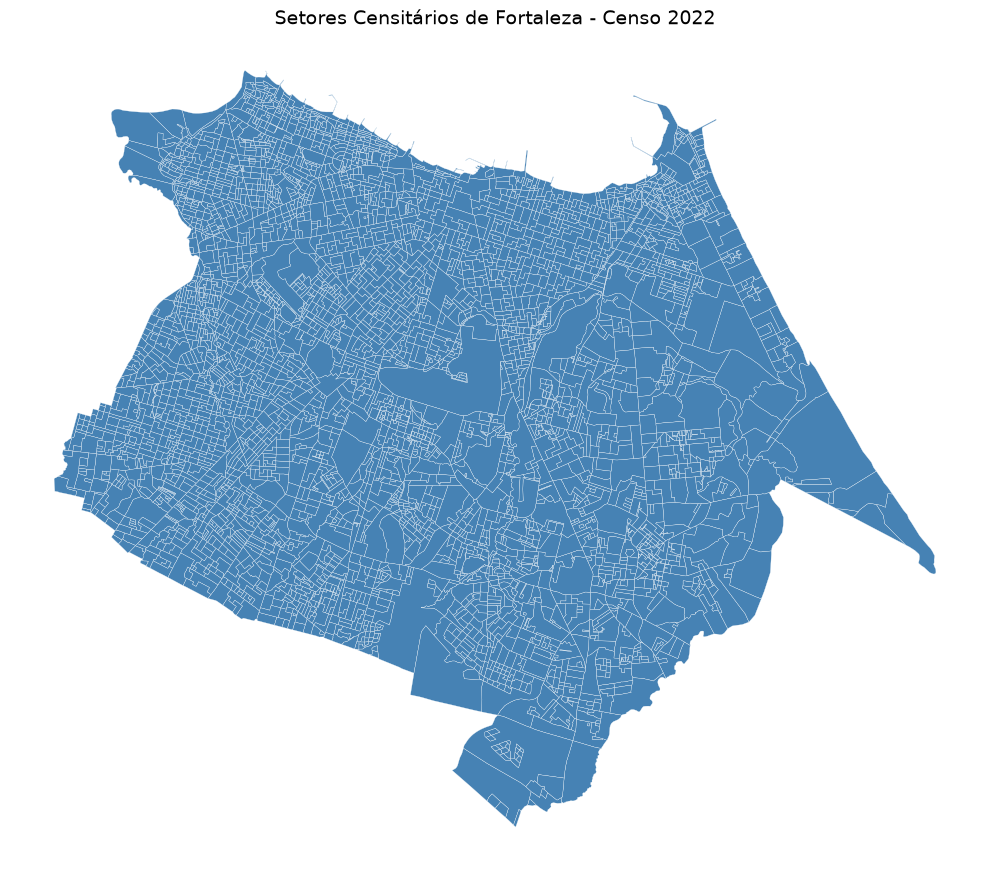

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
setores_fortaleza.plot(ax=ax, color="steelblue", edgecolor="white", linewidth=0.2)
ax.set_title("Setores Censitários de Fortaleza - Censo 2022", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Dados Demográficos Agregados por Setor

O arquivo `Agregados_por_setores_demografia_BR.csv` contém variáveis demográficas do [Censo 2022](https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html?edicao=41852&t=resultados) (Pessoas), para todos os setores censitários do Brasil.

O separador é `;` (ponto e vírgula) e os campos estão entre aspas duplas, padrão comum nos arquivos IBGE.

In [8]:
demograficos = pd.read_csv(
    "data/Agregados_por_setores_demografia_BR.csv",
    sep=";",
    dtype={"CD_setor": str},
)

print(f"Setores no arquivo (Brasil): {len(demograficos):,}")
print(f"Variáveis: {len(demograficos.columns)}")
demograficos.head(3)

Setores no arquivo (Brasil): 458,772
Variáveis: 37


/tmp/ipykernel_101334/713156811.py:1: DtypeWarning: Columns (0: V01006, 1: V01007, 2: V01008, 3: V01009, 4: V01014, 5: V01023, 6: V01030, 7: V01037, 8: V01038, 9: V01039) have mixed types. Specify dtype option on import or set low_memory=False.
  demograficos = pd.read_csv(


,CD_setor,V01006,V01007,V01008,V01009,V01010,V01011,V01012,V01013,V01014,...,V01032,V01033,V01034,V01035,V01036,V01037,V01038,V01039,V01040,V01041
0,110001505000002,928,428,500,30,39,24,44,36,25,...,68,62,88,68,58,144,129,124,66,53
1,110001505000003,556,270,286,15,20,20,19,30,20,...,36,47,38,47,44,83,95,48,47,34
2,110001505000004,222,108,114,5,4,9,14,7,5,...,11,15,26,11,11,33,37,25,23,17


### Dicionário de variáveis - Agregados Demográficos (Tabela 01)

Fonte: documentação dos Agregados por Setores Censitários, [Censo 2022](https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html?edicao=41852&t=resultados).

| Coluna | Descrição |
|--------|-----------|
| `CD_setor` | Geocódigo do setor censitário - chave de junção com a malha |
| `V01006` | Total de pessoas residentes |
| `V01007` | Homens (total) |
| `V01008` | Mulheres (total) |
| `V01009` | 0 anos |
| `V01010` | 1 a 4 anos |
| `V01011` | 5 a 9 anos |
| `V01012` | 10 a 14 anos |
| `V01013` | 15 a 19 anos |
| `V01014` | 20 a 24 anos |
| `V01015` | 25 a 29 anos |
| `V01016` | 30 a 34 anos |
| `V01017` | 35 a 39 anos |
| `V01018` | 40 a 44 anos |
| `V01019` | 45 a 49 anos |
| `V01020` | 50 a 54 anos |
| `V01021` | 55 a 59 anos |
| `V01022` | 60 a 64 anos |
| `V01023` | 65 a 69 anos |
| `V01024` | 70 a 74 anos |
| `V01025` | 75 a 79 anos |
| `V01026` | 80 a 84 anos |
| `V01027` | 85 a 89 anos |
| `V01028` | 90 a 94 anos |
| `V01029` | 95 a 99 anos |
| `V01030` | 100 anos ou mais |
| `V01031`–`V01041` | Variáveis demográficas complementares (ver documentação IBGE) |

> As variáveis `V01009` a `V01030` somam o total de `V01006` para cada setor.

## 5. Integrando os Dados

Para combinar a malha geográfica com os dados demográficos, fazemos um **merge** usando o geocódigo do setor (`CD_SETOR` na malha e `CD_setor` no CSV) como chave de junção.

Antes do merge, é necessário padronizar o nome da coluna-chave e garantir que ambas as colunas são do tipo `str`, já que os geocódigos são identificadores textuais com zeros à esquerda significativos.

In [6]:
demograficos = demograficos.rename(columns={"CD_setor": "CD_SETOR"})

setores_fortaleza = setores_fortaleza.merge(
    demograficos,
    on="CD_SETOR",
    how="left",
)

n_sem_dados = setores_fortaleza["V01006"].isna().sum()
print(f"Setores sem dados demográficos: {n_sem_dados} de {len(setores_fortaleza)}")
setores_fortaleza[["CD_SETOR", "NM_BAIRRO", "AREA_KM2", "V01006", "V01007", "V01008"]].head()

Setores sem dados demográficos: 102 de 4408


,CD_SETOR,NM_BAIRRO,AREA_KM2,V01006,V01007,V01008
0,230440005130001,Centro,0.044470,866,411,455
1,230440005130002,Centro,0.186817,35,22,13
2,230440005130003,Centro,0.316550,125,66,59
3,230440005130004,Centro,0.412278,266,125,141
4,230440005130005,Centro,0.118974,X,X,X


### Visualização: Densidade Populacional por Setor

Calculamos a **densidade populacional** (habitantes por km²) dividindo o total de pessoas (`V01006`) pela área do setor (`AREA_KM2`). Esse indicador revela a distribuição espacial da população dentro da cidade.

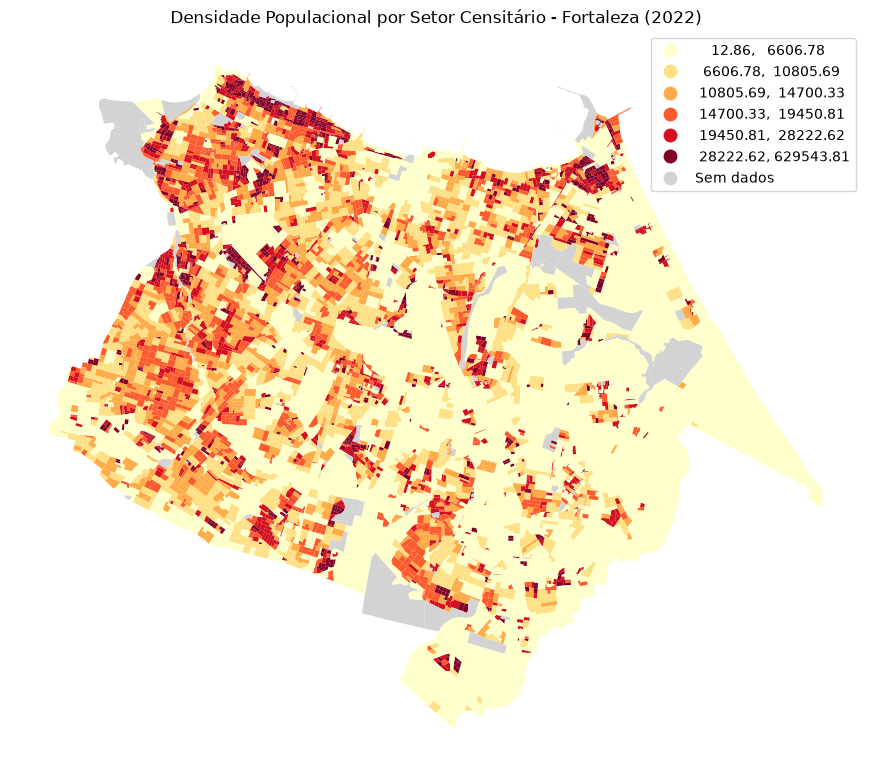

In [22]:
setores_fortaleza["V01006"] = pd.to_numeric(
    setores_fortaleza["V01006"],
    errors="coerce"
)

setores_fortaleza["AREA_KM2"] = pd.to_numeric(
    setores_fortaleza["AREA_KM2"],
    errors="coerce"
)

setores_fortaleza["densidade_hab_km2"] = (
    setores_fortaleza["V01006"] /
    setores_fortaleza["AREA_KM2"]
)

fig, ax = plt.subplots(figsize=(11, 11))

setores_fortaleza.plot(
    column="densidade_hab_km2",
    scheme="quantiles",
    k=6,
    cmap="YlOrRd",
    legend=True,
    edgecolor="none",
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dados"
    },
    ax=ax
)

ax.set_title("Densidade Populacional por Setor Censitário - Fortaleza (2022)")
ax.set_axis_off()

plt.show()

### Visualização: Densidade Populacional por Bairro com plotly

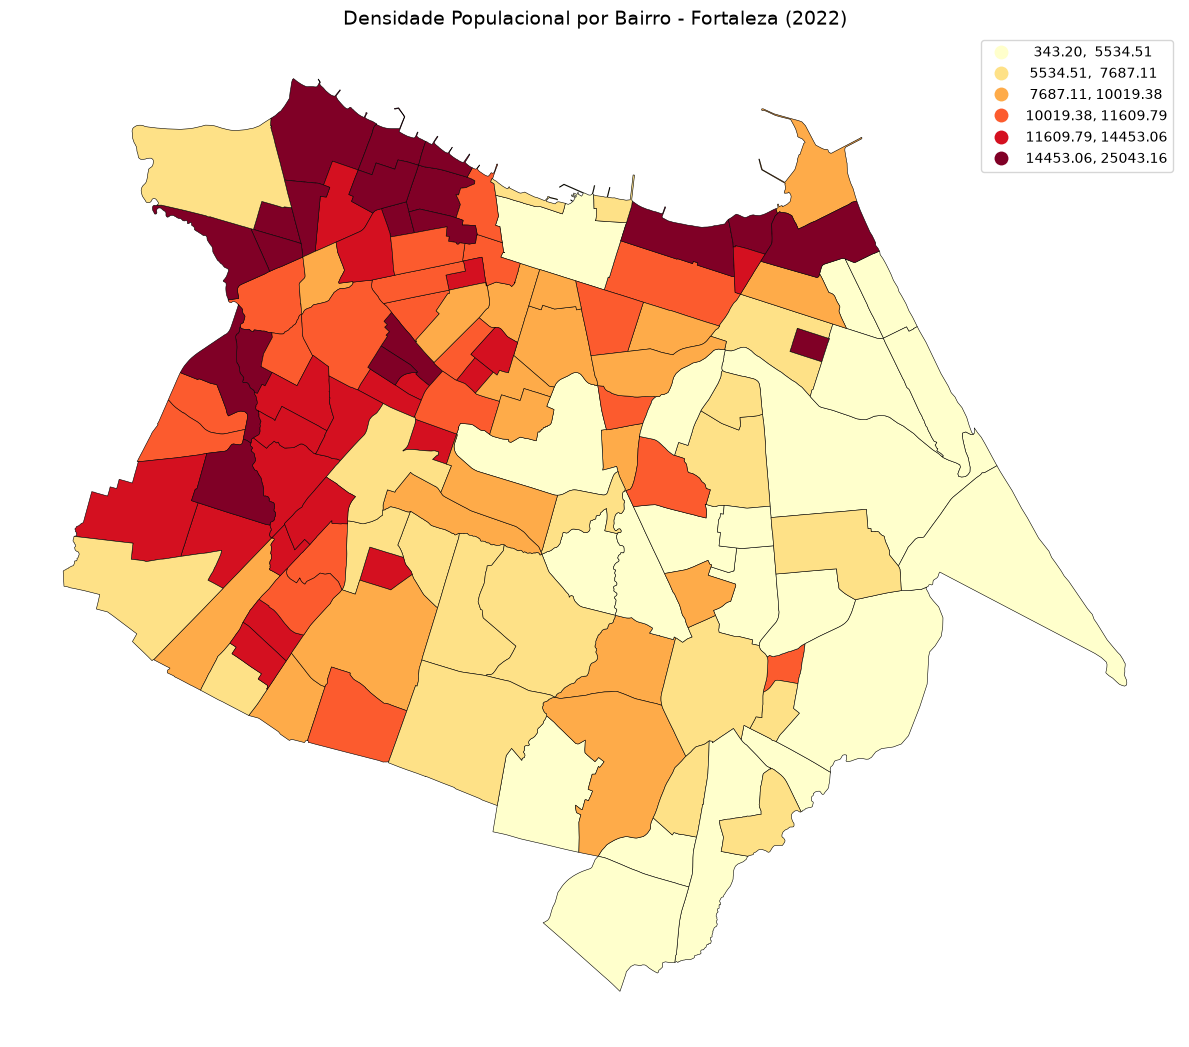

In [29]:
setores_fortaleza["V01006"] = pd.to_numeric(
    setores_fortaleza["V01006"],
    errors="coerce"
)

setores_fortaleza["AREA_KM2"] = pd.to_numeric(
    setores_fortaleza["AREA_KM2"],
    errors="coerce"
)

bairros = (
    setores_fortaleza
    .dissolve(
        by="NM_BAIRRO",
        aggfunc={
            "V01006": "sum",
            "AREA_KM2": "sum"
        }
    )
    .reset_index()
)

bairros["densidade_hab_km2"] = (
    bairros["V01006"] /
    bairros["AREA_KM2"]
)



fig, ax = plt.subplots(figsize=(12, 12))

bairros.plot(
    column="densidade_hab_km2",
    scheme="quantiles",
    k=6,
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dados"
    },
    ax=ax
)

ax.set_title(
    "Densidade Populacional por Bairro - Fortaleza (2022)",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()


### 10 bairros mais densamentes povoados de Fortaleza

In [33]:
print(bairros.groupby("NM_BAIRRO")["densidade_hab_km2"].sum().nlargest(10))

NM_BAIRRO
Pirambu             25043.160055
Cristo Redentor     20683.628618
Autran Nunes        19063.232288
Carlito Pamplona    17491.643053
Jardim Iracema      17206.496600
Jardim Guanabara    16798.996615
Genibaú             16472.008117
Mucuripe            15731.750339
Cidade 2000         15721.859056
Olavo Oliveira      15673.085871
Name: densidade_hab_km2, dtype: float64


In [34]:
renda = pd.read_csv(
    "data/Agregados_por_setores_renda_responsavel_BR.csv",
    sep=";",
    encoding="latin1"
)
renda.head()
renda.columns.tolist()
renda.info()

<class 'pandas.DataFrame'>
RangeIndex: 458772 entries, 0 to 458771
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   CD_SETOR  458772 non-null  int64
 1   V06001    458772 non-null  str  
 2   V06002    458772 non-null  str  
 3   V06003    458772 non-null  str  
 4   V06004    458772 non-null  str  
 5   V06005    458772 non-null  str  
 6   V06006    458772 non-null  str  
dtypes: int64(1), str(6)
memory usage: 24.5 MB


In [35]:
setores_fortaleza.columns

Index(['CD_SETOR', 'SITUACAO', 'CD_SIT', 'CD_TIPO', 'AREA_KM2', 'NM_BAIRRO',
       'geometry', 'V01006', 'V01007', 'V01008', 'V01009', 'V01010', 'V01011',
       'V01012', 'V01013', 'V01014', 'V01015', 'V01016', 'V01017', 'V01018',
       'V01019', 'V01020', 'V01021', 'V01022', 'V01023', 'V01024', 'V01025',
       'V01026', 'V01027', 'V01028', 'V01029', 'V01030', 'V01031', 'V01032',
       'V01033', 'V01034', 'V01035', 'V01036', 'V01037', 'V01038', 'V01039',
       'V01040', 'V01041', 'densidade_hab_km2'],
      dtype='str')

In [36]:
renda.columns

Index(['CD_SETOR', 'V06001', 'V06002', 'V06003', 'V06004', 'V06005', 'V06006'], dtype='str')

In [39]:
setores_fortaleza["CD_SETOR"] = (
    setores_fortaleza["CD_SETOR"]
    .astype(str)
)

renda["CD_SETOR"] = (
    renda["CD_SETOR"]
    .astype(str)
)

setores_renda = setores_fortaleza.merge(
    renda,
    on="CD_SETOR",
    how="left"
)

### Vendo o dicionário de renda

In [49]:
import pandas as pd
dicio_renda = pd.read_excel(
    "data/dicionario_de_dados_renda_responsavel_20260508.xlsx"
)

print(f"Linhas do dicionário: {len(dicio_renda):,}")
print(f"Colunas: {len(dicio_renda.columns)}")

print(dicio_renda.head(56).to_string(index=False))

Linhas do dicionário: 6
Colunas: 3
                Tema Variável                                                                                                                            Descrição
Renda do Responsável   V06001                                                                 Pessoas responsáveis em domicílios particulares permanentes ocupados
Renda do Responsável   V06002                                                                            Moradores em domicílios particulares permanentes ocupados
Renda do Responsável   V06003                                                     Variância do número de moradores em domicílios particulares permanentes ocupados
Renda do Responsável   V06004   Valor do rendimento nominal médio mensal das pessoas responsáveis com rendimentos por domicílios particulares permanentes ocupados
Renda do Responsável   V06005     Variância do rendimento nominal mensal das pessoas responsáveis com rendimentos por domicílios particulares permanen

/home/natan/Área de trabalho/Trabalho - LCD/desigualdades-socioespaciais-fortaleza/.venv/lib/python3.11/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 6 classes. Setting k to 5.
  self.bins = quantile(y, k=k)


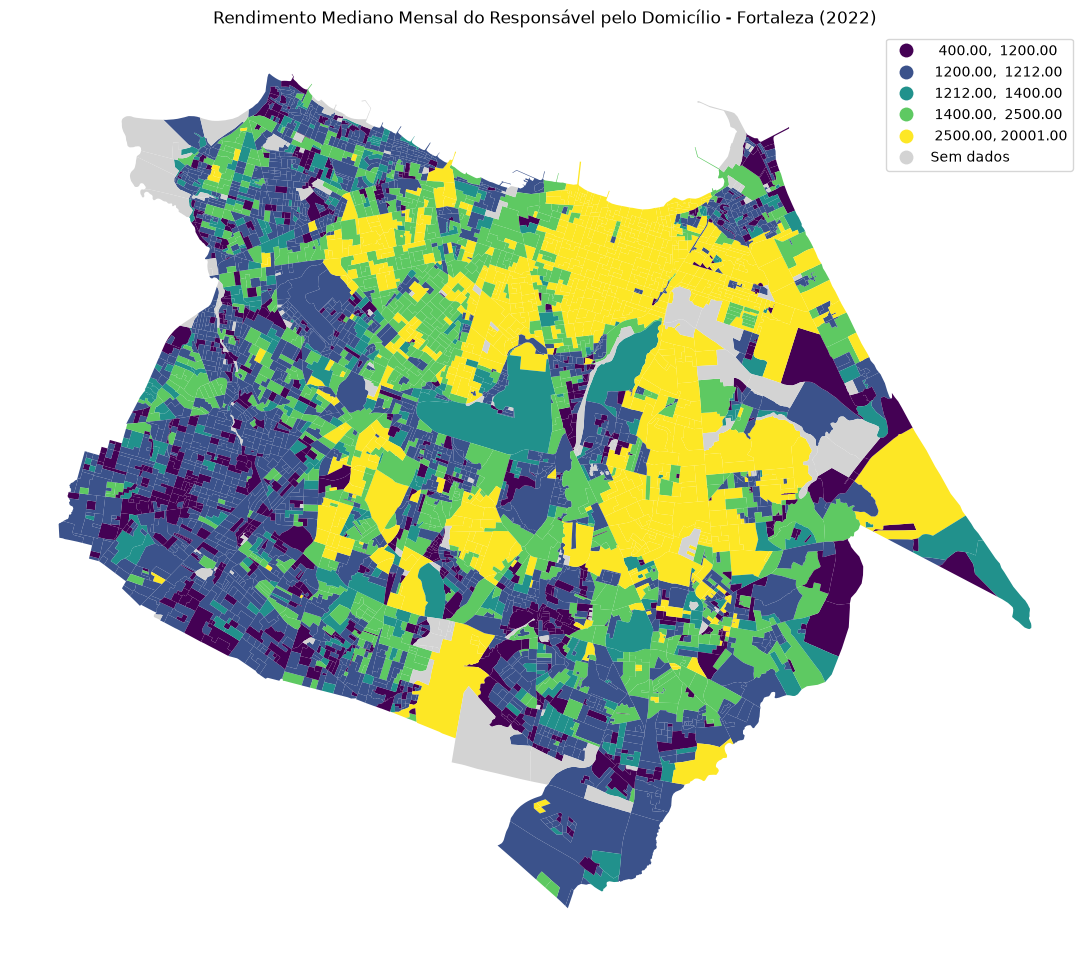

In [54]:
setores_renda["V06006"] = pd.to_numeric(
    setores_renda["V06006"],
    errors="coerce"
)

fig, ax = plt.subplots(figsize=(11, 11))

setores_renda.plot(
    column="V06006",
    scheme="quantiles",
    k=6,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dados"
    },
    ax=ax
)

ax.set_title(
    "Rendimento Mediano Mensal do Responsável pelo Domicílio - Fortaleza (2022)"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

### Renda por bairro

/home/natan/Área de trabalho/Trabalho - LCD/desigualdades-socioespaciais-fortaleza/.venv/lib/python3.11/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 6 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


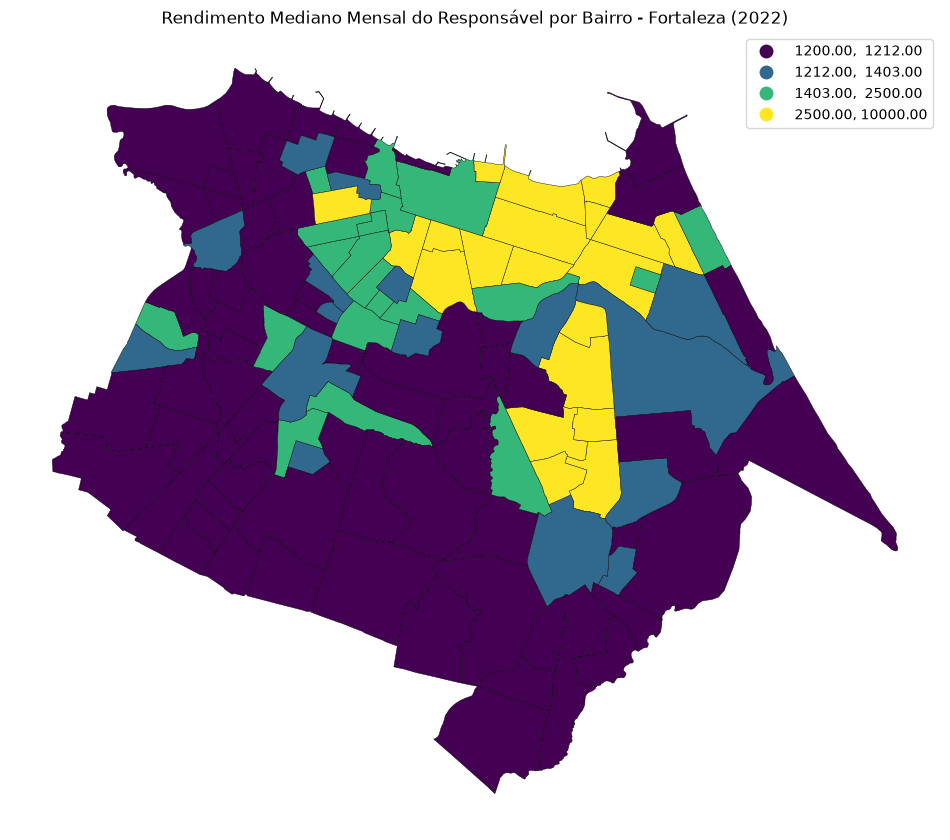

In [55]:
bairros_renda = (
    setores_renda
    .dissolve(
        by="NM_BAIRRO",
        aggfunc={
            "V06006": "median"
        }
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 12))

bairros_renda.plot(
    column="V06006",
    scheme="quantiles",
    k=6,
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

ax.set_title(
    "Rendimento Mediano Mensal do Responsável por Bairro - Fortaleza (2022)"
)

ax.set_axis_off()
plt.show()

### 10 bairros com maiores rendimentos medianos

In [56]:
bairros_renda.sort_values(
    "V06006",
    ascending=False
)[["NM_BAIRRO", "V06006"]].head(10)

,NM_BAIRRO,V06006
26,Cocó,10000.0
51,Guararapes,10000.0
71,Meireles,9250.0
2,Aldeota,8000.0
39,Dionísio Torres,7000.0
86,Parque Iracema,6000.0
115,Varjota,5000.0
46,Fátima,5000.0
35,De Lourdes,5000.0
19,Cambeba,4875.0


### 10 bairos com menores rendimentos


In [57]:
bairros_renda.sort_values(
    "V06006",
    ascending=True
)[["NM_BAIRRO", "V06006"]].head(10)

,NM_BAIRRO,V06006
10,Barroso,1200.0
0,Aerolândia,1206.0
88,Parque Presidente Vargas,1206.5
3,Alto da Balança,1212.0
7,Aracapé,1212.0
9,Barra do Ceará,1212.0
8,Autran Nunes,1212.0
1,Aeroporto,1212.0
15,Bom Jardim,1212.0
13,Boa Vista / Castelão,1212.0
